In [29]:
from typing_extensions import TypedDict
from typing import List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model("openai:gpt-4o-mini")


In [30]:

class State(TypedDict) :
    
    dish : str
    ingredients : list[dict]               # 재료
    recipe_steps : list[dict]              # 요리 순서
    plating_instructions : str      # 플레이팅 지침
    specific_instructions : str              # 사용자의 특이 재료

class Ingredient(BaseModel) :
    name : str
    quantity : str
    unit : str

# 구조화된 출력을 위한 구조체 [재료 목록]
class IngredientList(BaseModel) :
    ingredients : List[Ingredient]

# 식재료에 대해서 적합여부를 판단 결과
class InspectionResult(BaseModel) :
    opinion : str           # 판단 결과, 의견
    validity : bool           # 판단 최종 결과과

# 조리법 각 단계
class Recipe_Step(BaseModel) :
    step : int              # 몇번째 순서인지
    instruction : str       # 지침

# 조리법
class Recipe(BaseModel):
    steps : List[Recipe_Step] # 각단계의 모음음


In [31]:
def node_prepare_ingredients(state : State) :
    # 재료를 준비합니다.

    llm_ingredientsList = llm.with_structured_output(IngredientList)

    received_ingredientList = llm_ingredientsList.invoke(
        f" 음식 {state['dish']} 을 만들기 위한 n개의 재료를 준비해봐"
    )

    return {
        "ingredients" : received_ingredientList.ingredients
    }

# 유저가 먹지 못하는 재료가 있는지 검사
def gate(state : State):

    inspectionResult_llm = llm.with_structured_output(InspectionResult)
    inspectionResult = inspectionResult_llm.invoke(
        f"""    음식 {state["dish"]} 을 만들기위한 재료 ({state["ingredients"]}) 들이 있는데, 
                손님의 요구사항을 고려했을때 재료들이 타당한지 판단하고 결과를 알려줘.
                만약 타당하지 않다면, validity 값을 False 로 써주고, 그게 아니라면 True 야.

                손님의 요구사항 : 
                {state["specific_instructions"]}
        """
    )

    print(f"AI 요리사 :{inspectionResult.opinion}")

    print("validity : ", inspectionResult.validity)

    if(not inspectionResult.validity):
        print("\n부적합 판단되어 종료합니다.\n")
        return False

    return True


def node_write_recipe(state:State) :

    recipe_llm = llm.with_structured_output(Recipe)

    writed_recipe = recipe_llm.invoke(
        f"제공하는 재료들({state['ingredients']}) 를 사용하여 요리 '{state['dish']}' 를 단계별로 조리하는 방법을 작성하세요."
    )

    return {
        "recipe_steps" : writed_recipe.steps
    }

def node_describe_plating(state : State):
    
    llm_plating = llm.invoke(
        f"이 레시피 ({state['recipe_steps']}) 을 바탕으로 이 요리 '{state["dish"]}' 를 아름답게 플레이팅 하는 방법을 설명하세요"
    )

    return {
        "plating_instructions" : llm_plating.content
    }


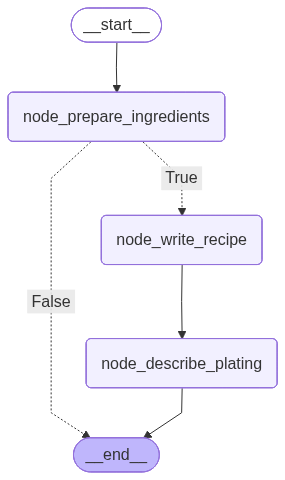

In [32]:
graph_builder = StateGraph(State)

graph_builder.add_node("node_prepare_ingredients",node_prepare_ingredients)
graph_builder.add_node("node_write_recipe",node_write_recipe)
graph_builder.add_node("node_describe_plating",node_describe_plating)

graph_builder.add_edge(START, "node_prepare_ingredients")
graph_builder.add_conditional_edges("node_prepare_ingredients", gate, {
    True : "node_write_recipe",
    False : END
})
graph_builder.add_edge("node_write_recipe","node_describe_plating")
graph_builder.add_edge("node_describe_plating",END)


graph = graph_builder.compile()

graph

In [33]:
graph.invoke({
    "dish":"커피",
    "specific_instructions" : "생리중이에요"
})

c:\HeukKell_Asset\ProjectFolder\Temporal\Python\GitHub\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=IngredientList(ingredient...'1', unit='작은술')]), input_type=IngredientList])
  return self.__pydantic_serializer__.to_python(
c:\HeukKell_Asset\ProjectFolder\Temporal\Python\GitHub\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=InspectionResult(opinion=...니다.', validity=True), input_type=InspectionResult])
  return self.__pydantic_serializer__.to_python(


AI 요리사 :손님이 생리 중이라는 요구사항을 고려할 때, 커피는 개인에 따라 생리통을 완화하거나 악화시킬 수 있으며, 카페인 섭취에 대해 주의가 필요할 수 있습니다. 하지만 이 레시피의 재료들은 일반적으로 생리 중에도 섭취 가능한 재료들입니다. 물론, 개인의 상태에 따라 다를 수 있습니다.
validity :  True


c:\HeukKell_Asset\ProjectFolder\Temporal\Python\GitHub\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Recipe(steps=[Recipe_Step...피를 즐기세요!')]), input_type=Recipe])
  return self.__pydantic_serializer__.to_python(


{'dish': '커피',
 'ingredients': [Ingredient(name='커피 원두', quantity='2', unit='컵'),
  Ingredient(name='물', quantity='4', unit='컵'),
  Ingredient(name='우유', quantity='1', unit='컵'),
  Ingredient(name='설탕', quantity='2', unit='큰술'),
  Ingredient(name='시나몬 가루', quantity='1', unit='작은술'),
  Ingredient(name='바닐라 추출물', quantity='1', unit='작은술')],
 'recipe_steps': [Recipe_Step(step=1, instruction='커피 원두를 분쇄하여 준비합니다.'),
  Recipe_Step(step=2, instruction='냄비에 물 4컵을 붓고 끓입니다.'),
  Recipe_Step(step=3, instruction='끓는 물에 분쇄한 커피 원두를 넣고 4-5분 동안 우려냅니다.'),
  Recipe_Step(step=4, instruction='우려낸 커피를 체에 걸러서잔에 붓습니다.'),
  Recipe_Step(step=5, instruction='잔에 우유 1컵을 추가합니다.'),
  Recipe_Step(step=6, instruction='설탕 2큰술을 넣고 잘 저어줍니다.'),
  Recipe_Step(step=7, instruction='시나몬 가루 1작은술을 추가하여 다시 한 번 저어줍니다.'),
  Recipe_Step(step=8, instruction='바닐라 추출물 1작은술을 넣고 따라 잔에 담습니다.'),
  Recipe_Step(step=9, instruction='원하는 경우, 시나몬 가루를 추가로 뿌려서 장식합니다.'),
  Recipe_Step(step=10, instruction='따뜻한 커피를 즐기세요!')],
 'plating_instructions

In [34]:
graph.invoke({
    "dish":"커피",
    "specific_instructions" : "생리중이에요"
})

c:\HeukKell_Asset\ProjectFolder\Temporal\Python\GitHub\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=IngredientList(ingredient...ntity='50', unit='ml')]), input_type=IngredientList])
  return self.__pydantic_serializer__.to_python(


AI 요리사 :커피와 설탕, 우유, 생크림은 생리 중에 먹기 적합하지 않을 수 있습니다. 커피는 카페인이 들어 있어 몸에 수분을 감소시키고 불편을 유발할 수 있으며, 설탕과 생크림은 소화에 부담을 줄 수 있습니다.
validity :  False

부적합 판단되어 종료합니다.



c:\HeukKell_Asset\ProjectFolder\Temporal\Python\GitHub\Langgraph_Workflow\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=InspectionResult(opinion=...다.', validity=False), input_type=InspectionResult])
  return self.__pydantic_serializer__.to_python(


{'dish': '커피',
 'ingredients': [Ingredient(name='커피 원두', quantity='30', unit='g'),
  Ingredient(name='물', quantity='500', unit='ml'),
  Ingredient(name='설탕', quantity='2', unit='티스푼'),
  Ingredient(name='우유', quantity='100', unit='ml'),
  Ingredient(name='생크림', quantity='50', unit='ml')],
 'specific_instructions': '생리중이에요'}